# 03 - UNetV2: multiscale conditional denoising

UNetV2 revises the denoising architecture while retaining the pixel-space diffusion process and velocity objective of notebook 01. The design addresses two requirements: adapting feature processing to the current noise level and preserving spatial sketch information during image reconstruction.

The network adds scale-shift timestep conditioning, residual resolution changes and direct sketch features in the decoder. Self-attention operates at $32\times32$ and $16\times16$, where interactions across the face can be represented with fewer spatial tokens. Training starts from random initialization at $256\times256$; no pretrained image generator is used.

Embedded training results: September 30, 2026, RTX 4090; 12 epochs. Figures are rendered from that completed run.

In [1]:
from pathlib import Path
from copy import deepcopy
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from models.diffusion import Diffusion
from models.unet_v2 import UNetV2
from utils.data import make_dataloader, denormalize
from utils.visualization import show_generation_grid

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Training pairs and validation design

The training pairs use the shared affine, crop and reflection transforms defined in notebook 01. A held-out subset of 128 unaugmented pairs supplies the denoising diagnostic, while its first four sketches provide fixed generation previews.

Validation reuses the same diffusion timesteps and Gaussian noise at every epoch. Consequently, changes in validation loss reflect changes in the EMA model under a fixed set of corruption conditions, rather than a newly sampled evaluation task.

In [2]:
manifest_path = ROOT / 'data/processed/pairs.csv'
train_loader = make_dataloader(
    manifest_path, split='train', image_size=256, batch_size=8,
    repeat=1, num_workers=2, random_transform=True, affine=True,
)
val_loader = make_dataloader(
    manifest_path, split='val', image_size=256, batch_size=8,
    max_items=128, shuffle=False, num_workers=2, random_transform=False,
)
preview_sketches, preview_photos = next(iter(val_loader))
sample_noise = torch.randn(
    4, 3, 256, 256, generator=torch.Generator().manual_seed(123),
).to(device)
print(f'Train pairs: {train_loader.dataset.num_pairs:,}; validation diagnostic: {val_loader.dataset.num_pairs}')

Train pairs: 21,913; validation diagnostic: 128


## Architecture and parameterization

The original U-Net adds a timestep-dependent vector to its features. UNetV2 instead predicts a channelwise scale and shift for normalized activations:

$$h'=(1+\gamma_\theta(t))\odot\operatorname{GroupNorm}(h)+\delta_\theta(t).$$

Both vectors are computed from the timestep embedding and broadcast over spatial positions. This lets the noise level modulate feature amplitudes as well as offsets. Each encoder scale combines a residual downsampling block with a refinement block. In the decoder, an upsampling block is followed by fusion and refinement; fusion receives the upsampled activations, the encoder skip and the corresponding sketch features:

$$h_\ell^{\mathrm{fused}}=F_{\theta,\ell}\!\left(
[\operatorname{Up}(h_{\ell+1}),h_\ell^{\mathrm{skip}},S_\ell(s)],t\right).$$

Thus, high-resolution reconstruction can access sketch structure directly instead of relying entirely on the bottleneck or image skip path. Residual output convolutions and attention output projections are zero-initialized, so these branches initially contribute no correction to their skip paths. The velocity output head is also zero-initialized.

The diffusion target and loss remain unchanged:

$$v=\sqrt{\bar\alpha_t}\,\epsilon-\sqrt{1-\bar\alpha_t}\,x_0,
\qquad \hat x_0=\sqrt{\bar\alpha_t}\,x_t-\sqrt{1-\bar\alpha_t}\,v_\theta,$$

$$\mathcal L=\operatorname{MSE}(v_\theta,v)+0.25\,\operatorname{MAE}(\hat x_0,x_0).$$

Scale-shift normalization and residual resampling follow design choices in [ADM](https://arxiv.org/abs/2105.05233). The paired conditional-generation setting is also related to [Palette](https://arxiv.org/abs/2111.05826); UNetV2 is not a reproduction of either architecture.

In [3]:
model = UNetV2(
    n_channels=4, n_classes=3, base_channels=48, time_emb_dim=192,
    sketch_channels=1, dropout=0.1, use_attention=True,
).to(device)
ema_model = deepcopy(model).eval().requires_grad_(False)
diffusion = Diffusion(timesteps=1000, device=device, schedule='cosine')
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')
print(f'Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M')

Parameters: 41.48M


## Optimization and model averaging

AdamW trains the full model for 12 epochs with batches of eight, learning rate $2\times10^{-4}$ and weight decay $10^{-4}$. Generation and validation use an exponential moving average of the parameters,

$$\bar\theta_k=0.999\,\bar\theta_{k-1}+0.001\,\theta_k,$$

which smooths changes between successive optimizer updates. Training loss is measured on the current model with random augmentation and corruption; validation loss is measured on the EMA model with fixed corruption. Their curves therefore describe related but different evaluation conditions.

After each epoch, 60-step deterministic DDIM samples are generated from fixed noise. These panels complement the denoising loss: a lower average prediction error need not correspond to better facial structure along a complete sampling trajectory.

In [4]:
def update_ema(ema, source, decay=0.999):
    with torch.no_grad():
        for ema_p, p in zip(ema.parameters(), source.parameters()):
            ema_p.mul_(decay).add_(p, alpha=1 - decay)
        for ema_b, b in zip(ema.buffers(), source.buffers()):
            ema_b.copy_(b)

history, epoch_history, sample_history = [], [], []
checkpoint_dir = ROOT / 'checkpoints'
checkpoint_dir.mkdir(exist_ok=True)
checkpoint_path = checkpoint_dir / 'diffusion_sketch_faces_v2.pt'
preview_dir = ROOT / 'outputs/unet_v2'
preview_dir.mkdir(parents=True, exist_ok=True)
for epoch in range(1, 13):
    model.train()
    epoch_start = len(history)
    for step, (sketches, photos) in enumerate(tqdm(train_loader, desc=f'epoch {epoch}'), start=1):
        sketches, photos = sketches.to(device), photos.to(device)
        t = diffusion.sample_timesteps(photos.size(0))
        noisy_photos, noise = diffusion.add_noise(photos, t)
        target_v = diffusion.v_target(photos, noise, t)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            pred_v = model(torch.cat([sketches, noisy_photos], dim=1), t)
            pred_x0 = diffusion.predict_x0_from_v(noisy_photos, t, pred_v)
            # L = mean((v_theta - v)^2) + 0.25 * mean(|x_0_hat - x_0|).
            loss = F.mse_loss(pred_v, target_v) + 0.25 * F.l1_loss(pred_x0, photos)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        update_ema(ema_model, model)
        history.append(loss.item())
        if step % 100 == 0:
            print(f'epoch {epoch}/12 | step {step}/{len(train_loader)} | mean loss {sum(history[-100:]) / 100:.4f}', flush=True)

    validation_sum, validation_count = 0.0, 0
    val_rng = torch.Generator(device=device).manual_seed(456)
    with torch.no_grad():
        for sketches, photos in val_loader:
            sketches, photos = sketches.to(device), photos.to(device)
            t = torch.randint(0, diffusion.timesteps, (photos.size(0),), device=device, generator=val_rng)
            noise = torch.randn(photos.shape, device=device, generator=val_rng)
            noisy_photos, _ = diffusion.add_noise(photos, t, noise=noise)
            pred_v = ema_model(torch.cat([sketches, noisy_photos], dim=1), t)
            pred_x0 = diffusion.predict_x0_from_v(noisy_photos, t, pred_v)
            val_loss = F.mse_loss(pred_v, diffusion.v_target(photos, noise, t)) + 0.25 * F.l1_loss(pred_x0, photos)
            validation_sum += val_loss.item() * photos.size(0)
            validation_count += photos.size(0)
        generated = diffusion.ddim_sample(
            ema_model, preview_sketches[:4].to(device), steps=60, eta=0.0, noise=sample_noise,
        ).cpu()
    sample_history.append(generated)
    epoch_history.append(dict(epoch=epoch, train_loss=sum(history[epoch_start:]) / (len(history) - epoch_start),
                              val_loss=validation_sum / validation_count))
    print(epoch_history[-1], flush=True)
    pd.DataFrame(epoch_history).to_csv(preview_dir / 'metrics.csv', index=False)
    fig = show_generation_grid(preview_sketches[:4], generated, preview_photos[:4], n=4)
    fig.savefig(preview_dir / f'epoch_{epoch:02d}.png', dpi=100)
    plt.close(fig)
    torch.save(
        dict(model_name='UNetV2', model_args=model.model_args, epoch=epoch,
             model=model.state_dict(), ema=ema_model.state_dict(),
             history=history, epoch_history=epoch_history, sample_history=sample_history),
        checkpoint_path,
    )

epoch 1/12 | step 100/2739 | mean loss 0.5891


epoch 1/12 | step 200/2739 | mean loss 0.2853


epoch 1/12 | step 300/2739 | mean loss 0.1575


epoch 1/12 | step 400/2739 | mean loss 0.1300


epoch 1/12 | step 500/2739 | mean loss 0.1104


...

epoch 12/12 | step 2500/2739 | mean loss 0.0490


epoch 12/12 | step 2600/2739 | mean loss 0.0484


epoch 12/12 | step 2700/2739 | mean loss 0.0504


{'epoch': 12, 'train_loss': 0.05001227833213663, 'val_loss': 0.054070222191512585}


epoch 12/12 saved | total updates 32868


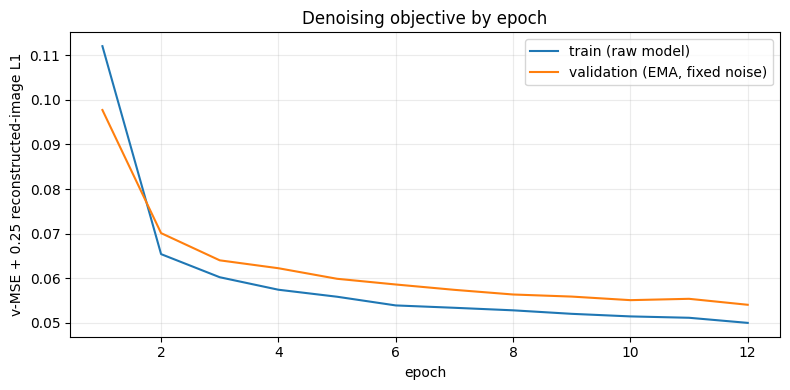

In [5]:
results = pd.DataFrame(epoch_history).set_index('epoch')
ax = results.rename(columns={'train_loss': 'train (raw model)', 'val_loss': 'validation (EMA, fixed noise)'}).plot(figsize=(8, 4))
ax.set_ylabel('v-MSE + 0.25 reconstructed-image L1')
ax.set_title('Denoising objective by epoch')
ax.grid(alpha=0.25)
plt.tight_layout()

In [6]:
display(results.tail(3))

,train_loss,val_loss
epoch,,
10,0.051464,0.055108
11,0.051158,0.055408
12,0.050012,0.054070


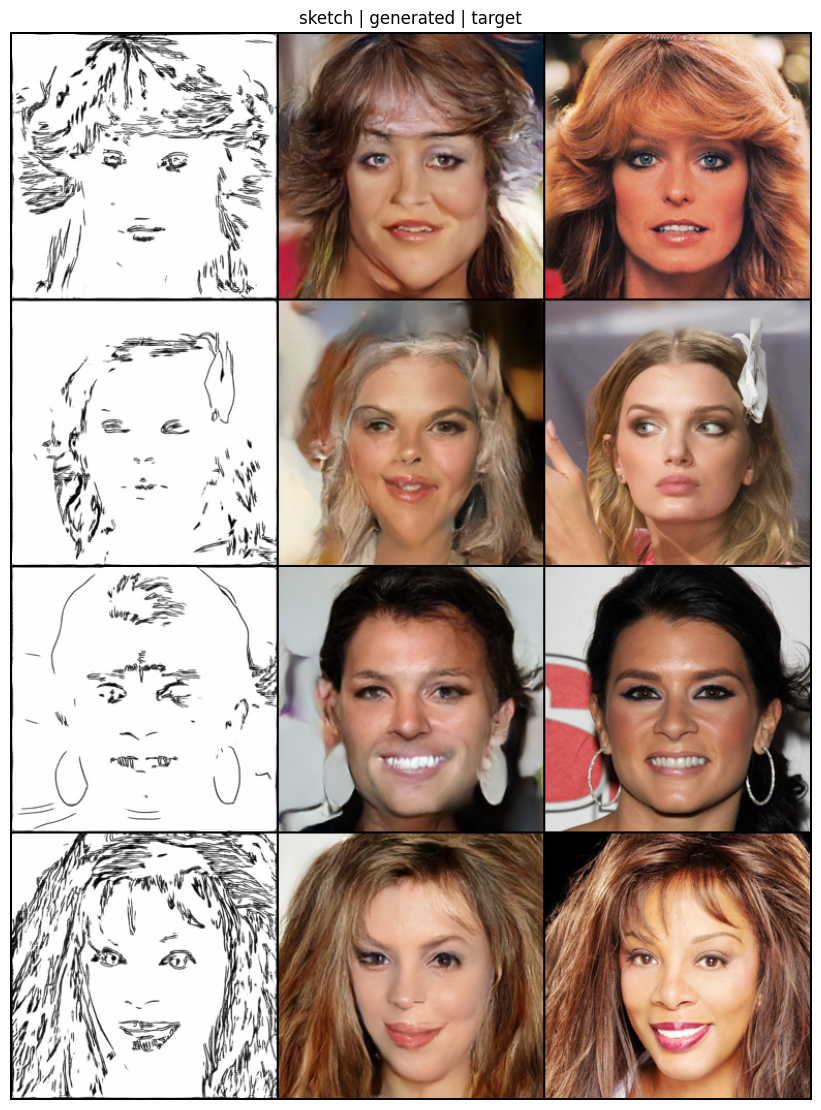

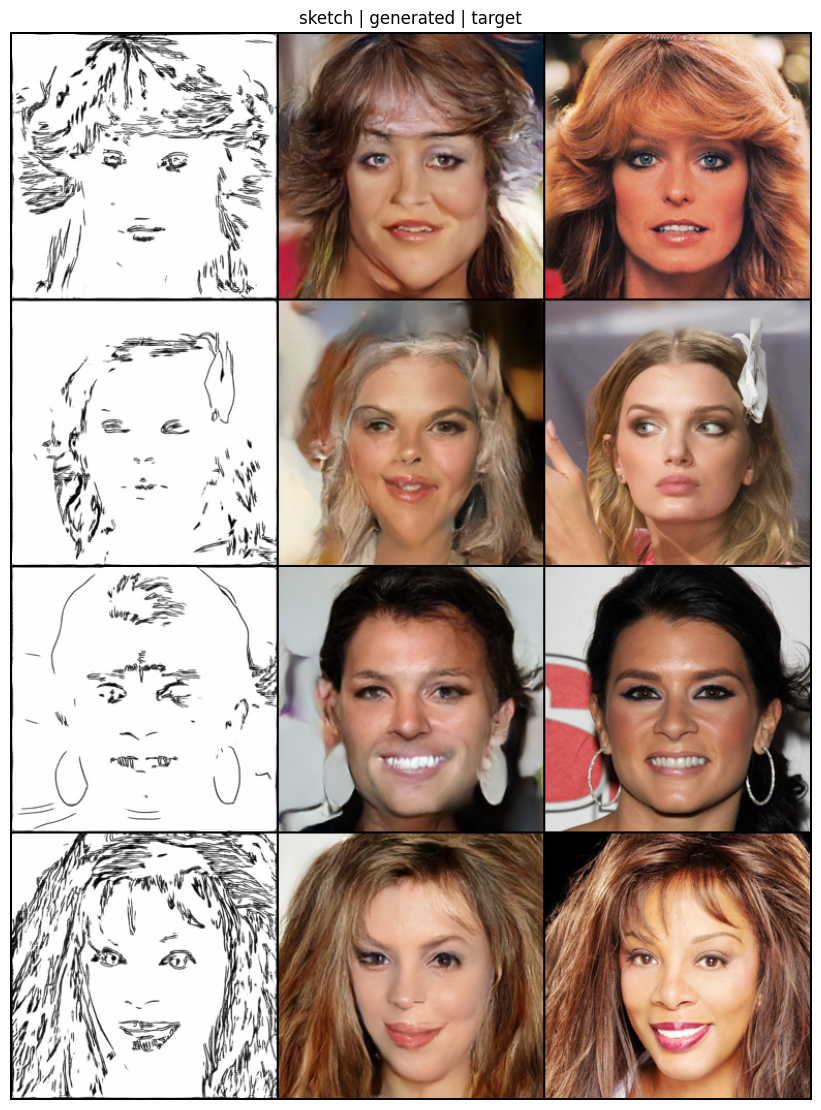

In [7]:
show_generation_grid(preview_sketches[:4], sample_history[-1], preview_photos[:4], n=4)

## Evolution of a fixed sample

The montage holds the sketch, initial Gaussian state and DDIM settings constant at epochs 1, 5, 9 and 12. Any change in the generated portrait is therefore attributable to the evolving EMA weights. This reveals whether additional optimization improves facial coherence and detail, or merely changes the training objective without a corresponding visual benefit.

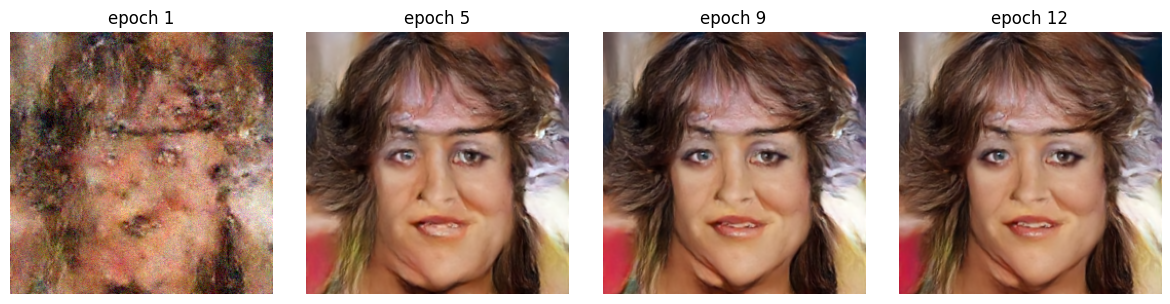

In [8]:
picks = [0, 4, 8, 11]
fig, axes = plt.subplots(1, len(picks), figsize=(3 * len(picks), 3), squeeze=False)
for ax, i in zip(axes[0], picks):
    ax.imshow(denormalize(sample_history[i][0]).permute(1, 2, 0))
    ax.set_title(f'epoch {i + 1}')
    ax.axis('off')
plt.tight_layout()